In [10]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

# 1- Load Libraries

In [2]:
suppressPackageStartupMessages({
library(tidyverse)
library(readxl)
library(janitor)
library(plotly)
library(patchwork)
library(openxlsx)
library(lubridate)
})

# 2- Load data

In [7]:
data_Weather_falher <- readxl::read_excel("data/Barley 28 R weather and soil data/Falher/Weather_falher_final.xlsx") %>% 
  clean_names()

data_Weather_Lethbridge <- readxl::read_excel("data/Barley 28 R weather and soil data/Lethbridge/Weather_lethbridge_final.xlsx") %>% 
  clean_names()

data_Weather_Vermilion <- readxl::read_excel("data/Barley 28 R weather and soil data/Vermilion/weather_vermilion_final.xlsx") %>% 
  clean_names()

irrigation_2022_lethbridge_mm = 114.3
irrigation_2023_lethbridge_mm = 198.12
irrigation_2024_lethbridge_mm = 203.2

weather_data <- data_Weather_falher %>% 
  bind_rows(data_Weather_Lethbridge) %>% 
  bind_rows(data_Weather_Vermilion)


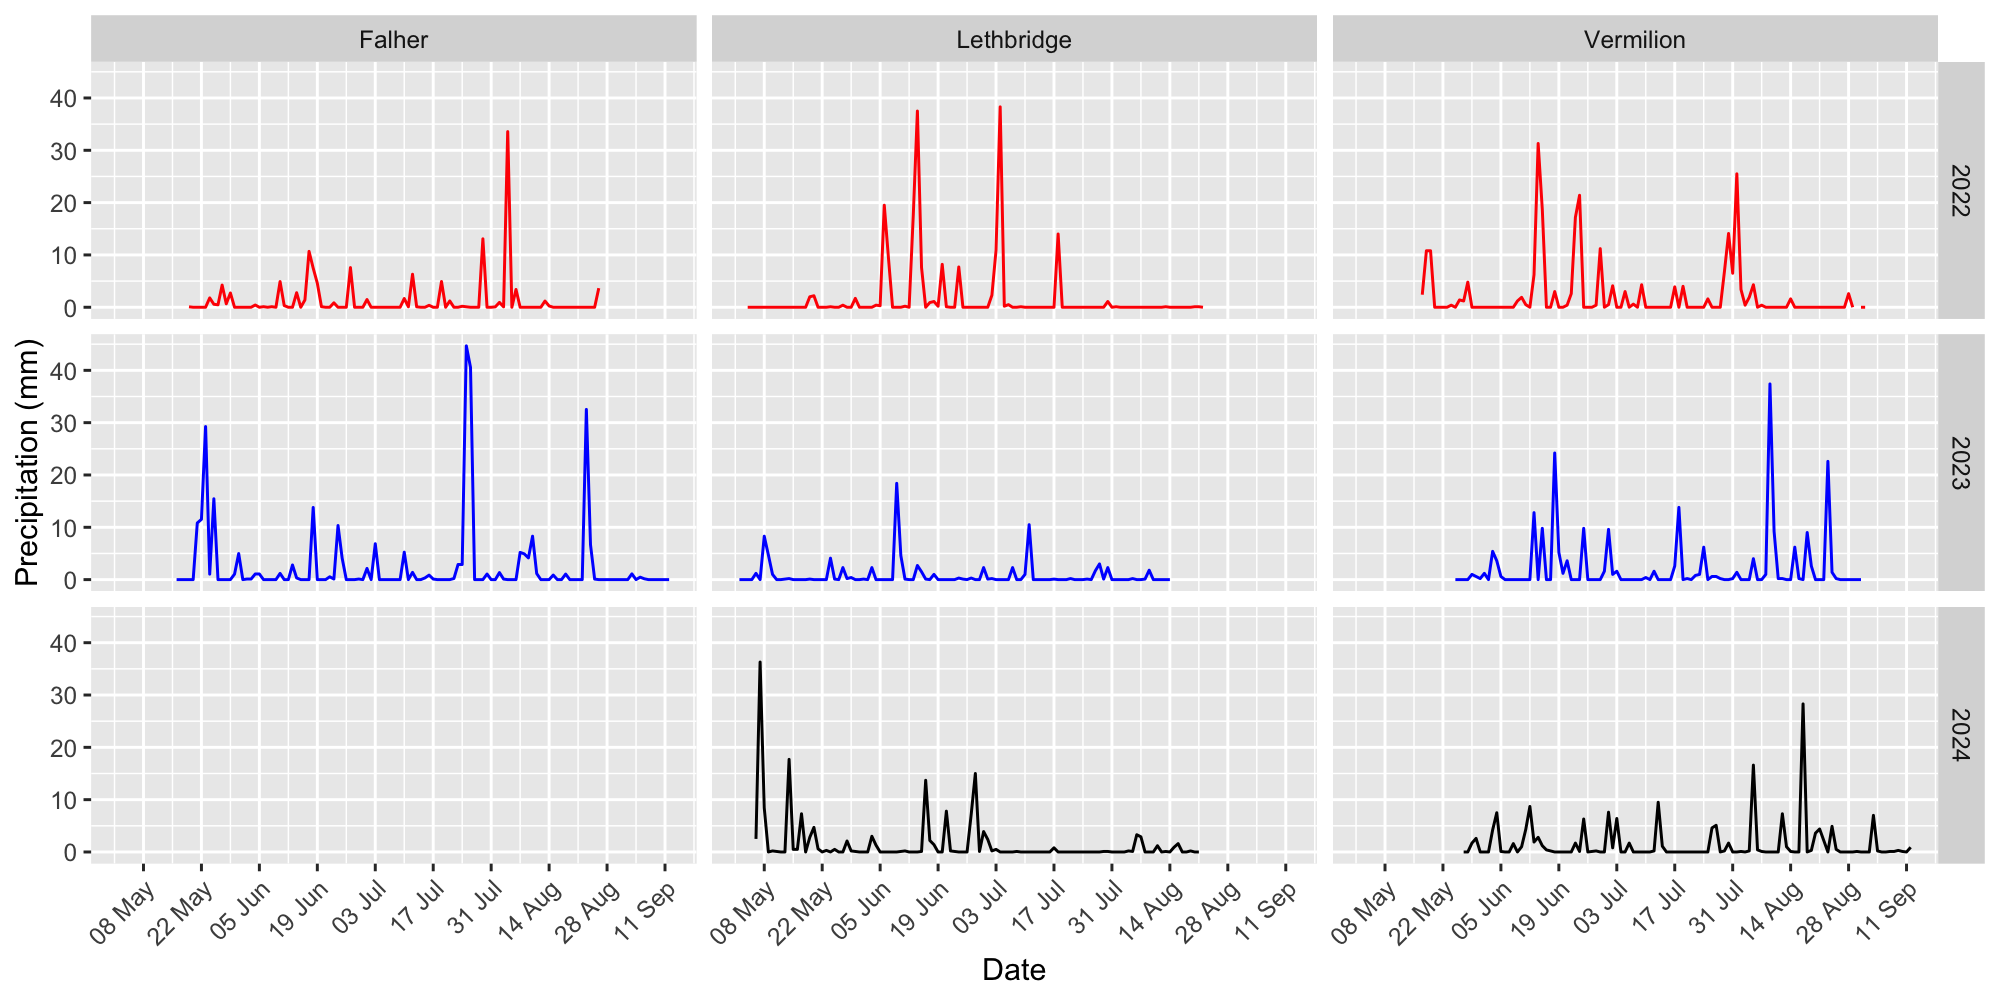

In [35]:
plot <- weather_data %>%
  mutate(
    date_local_standard_time = as.Date(date_local_standard_time),
    season_date = as.Date(sprintf("2000-%02d-%02d",
                                  month(date_local_standard_time),
                                  day(date_local_standard_time)))
  ) %>%
  filter(season_date <= as.Date("2000-10-10")) %>%   # up to Oct 10
  ggplot(aes(season_date, precip_mm, color = as.factor(year))) +
  geom_line(show.legend = FALSE) +
  facet_grid(year ~ location) +
  scale_color_manual(values = c("red", "blue", "black")) +
  scale_x_date(date_labels = "%d %b", date_breaks = "2 weeks") +
  labs(x = "Date", y = "Precipitation (mm)") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

plot

ggsave("figure/precipitation_1.png", width = 8, height = 5, dpi = 600)

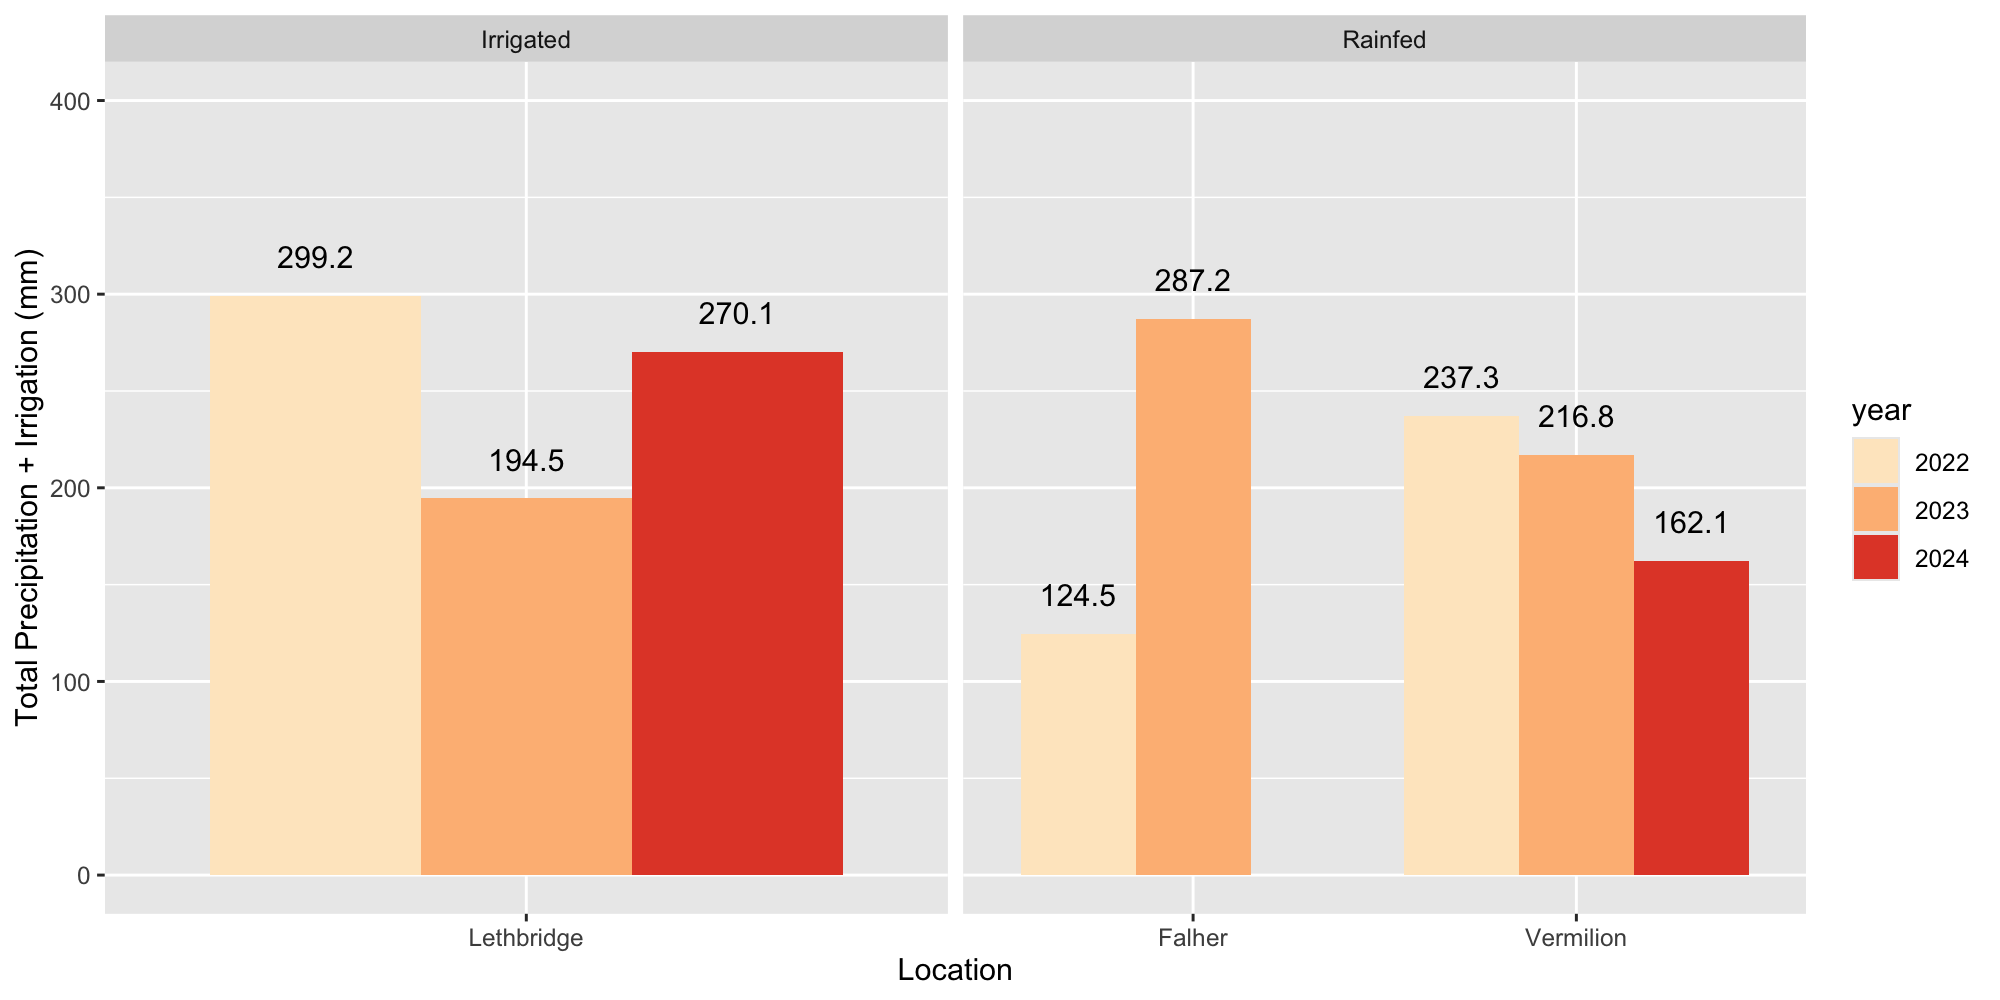

In [36]:
weather_monthly <- weather_data %>%
  mutate(
    date = as.Date(date_local_standard_time),
    year = factor(year),
    month = floor_date(date, "month")
  ) %>%
  filter(
    month(date) < 10 |
      (month(date) == 10 & day(date) <= 10)
  ) %>%
  filter(!(location == "Falher" & year == 2024)) %>% 
  group_by(year, location) %>%
  summarise(
    avg_precip_mm = sum(precip_mm, na.rm = TRUE),
    .groups = "drop"
  ) %>% 
  mutate(prec_irri = case_when(location == "Lethbridge" ~ avg_precip_mm + irrigation_2022_lethbridge_mm,
                               .default = avg_precip_mm
  ),
  irrig_group = case_when(location == "Lethbridge" ~ "Irrigated",
                               .default = "Rainfed"
  )
    )


ggplot(weather_monthly,
       aes(location, prec_irri, fill = year)) +
  geom_col(position = position_dodge(width = 0.9, preserve = "single")) +
  geom_text(
    aes(label = round(prec_irri, 1)),
    position = position_dodge(width = 0.9, preserve = "single"), vjust = -1.3
  ) +
  facet_grid(. ~ irrig_group, scales = "free_x")+
  scale_fill_brewer(type ="seq", palette = 8)+
 # scale_fill_manual(values = c("green4", "blue", "gray50")) +
  labs(
    x = "Location",
    y = "Total Precipitation + Irrigation (mm)"
  )+
  coord_cartesian(ylim = c(0, 400))

ggsave("figure/precipitation_2.png", width = 8, height = 5, dpi = 600)

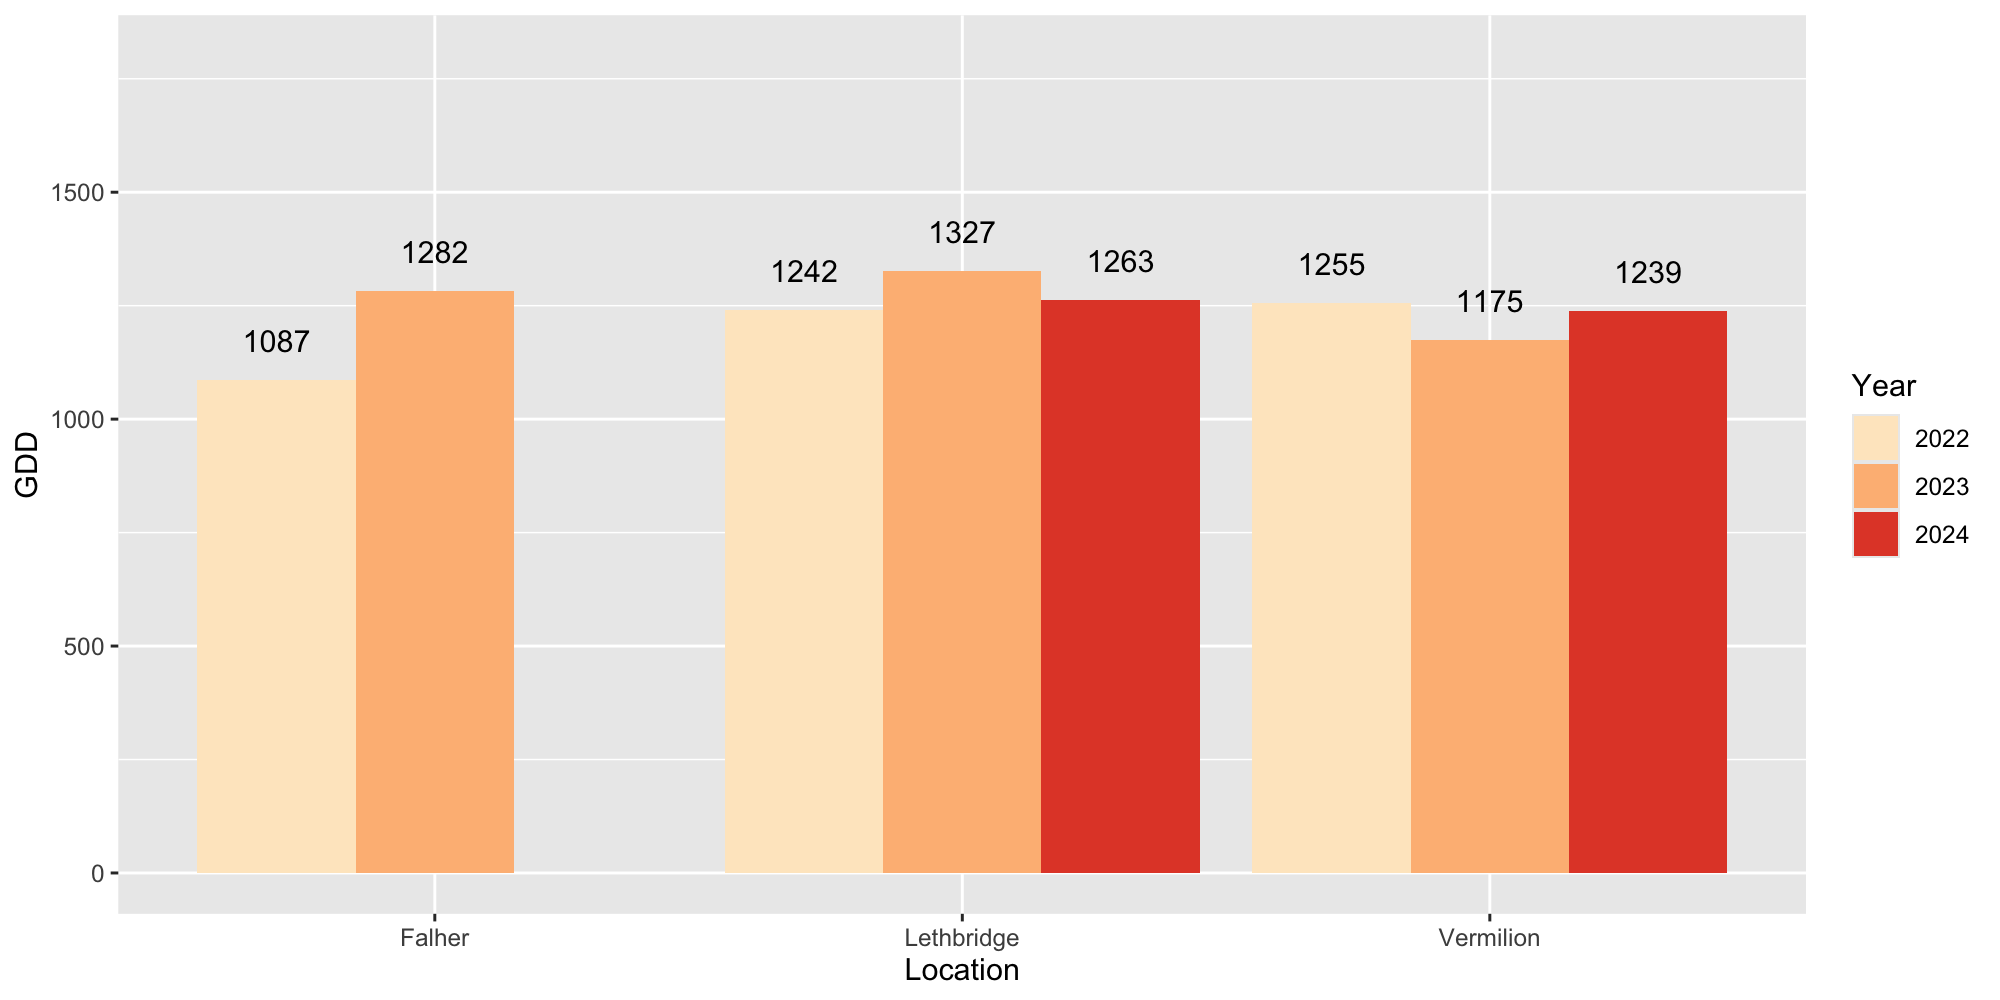

In [39]:
weather_data %>%
  filter(
    month(date_local_standard_time) < 10 |
    (month(date_local_standard_time) == 10 & day(date_local_standard_time) <= 10)
  ) %>%
  mutate(
    date_local_standard_time = as.Date(date_local_standard_time),
    doy = as.integer(format(date_local_standard_time, "%j")),
    GDD = ((air_temp_max_c + air_temp_min_c) / 2) - 5
  ) %>%
  group_by(location, year) %>% 
  summarise(sum_gdd = sum(GDD, na.rm = TRUE), .groups = "drop") %>% 
   ggplot(
       aes(location, sum_gdd, fill = as.factor(year))) +
  geom_col(position = position_dodge(width = 0.9, preserve = "single")) +
  geom_text(
    aes(label = round(sum_gdd, 0)),
    position = position_dodge(width = 0.9, preserve = "single"), vjust = -1.3
  ) +
  scale_fill_brewer(type ="seq", palette = 8)+
 # scale_fill_manual(values = c("green4", "blue", "gray50")) +
  labs(
    x = "Location",
    y = "GDD",
    fill = "Year"
  )+
  coord_cartesian(ylim = c(0, 1800))

ggsave("figure/GDD.png", width = 8, height = 5, dpi = 600)